# Edge Online learning for watrer level prediction

In [1]:
# import torch.optim as optim
import pandas as pd
import numpy as np
import util_fun as uf
from cstm_models import build_mlp 

### Training parameter

In [2]:
# --- Define Model Parameters ---
LOOKBACK = 48   # 48 hours of historical data
HORIZON = 24    # 24 hours of prediction
N_FEATURES = 4  # Q_bar, P_bar, T_bar, H_bar
BATCH_SIZE = 1  # we are using batch size of 1 for time series
H_BAR_INDEX = 3 # H_bar is the 4th feature (index 3)
EPSILON = 1e-6  # For numerical stability in normalization



In [3]:
train_df = pd.read_csv('dataset/one_station_train_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
test_df = pd.read_csv('dataset/one_station_test_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(train_df.info())
display(test_df.info())

x_train, y_train = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)
x_test, y_test = uf.create_sequences(test_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)

#Building datasets to be used by oytorch DataLoader
train_ds = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds  = uf.RollingNormTimeSeriesDataset(x_test, y_test, H_BAR_INDEX)



<class 'pandas.core.frame.DataFrame'>
Index: 59123 entries, 2009-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   59123 non-null  float64
 1   P_bar   59123 non-null  float64
 2   T_bar   59123 non-null  float64
 3   H_bar   59123 non-null  float64
dtypes: float64(4)
memory usage: 2.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 17524 entries, 2008-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   17524 non-null  float64
 1   P_bar   17524 non-null  float64
 2   T_bar   17524 non-null  float64
 3   H_bar   17524 non-null  float64
dtypes: float64(4)
memory usage: 684.5+ KB


None

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24
End of sufficient data at index 59064.
Total sequences created: 2461
 X shape: (2461, 48, 4), y shape: (2461, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24
End of sufficient data at index 17472.
Total sequences created: 728
 X shape: (728, 48, 4), y shape: (728, 24)


## Online Training using ADAM


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.331658
   Batch 200/2461, Loss: 0.032370
   Batch 300/2461, Loss: 0.223023
   Batch 400/2461, Loss: 0.078762
   Batch 500/2461, Loss: 0.013490
   Batch 600/2461, Loss: 0.417490
   Batch 700/2461, Loss: 7.548310
   Batch 800/2461, Loss: 0.045012
   Batch 900/2461, Loss: 208.959671
   Batch 1000/2461, Loss: 0.169868
   Batch 1100/2461, Loss: 6.357935
   Batch 1200/2461, Loss: 0.252108
   Batch 1300/2461, Loss: 0.020864
   Batch 1400/2461, Loss: 0.284032
   Batch 1500/2461, Loss: 0.023655
   Batch 1600/2461, Loss: 1.055545
   Batch 1700/2461, Loss: 3.924374
   Batch 1800/2461, Loss: 0.132259
   Batch 1900/2461, Loss: 194949496832.000000
   Batch 2000/2461, Loss: 0.214360
   Batch 2100/2461, Loss: 0.226520
   Batch 2200/2461, Loss: 0.673074
   Batch 2300/2461, Loss: 0.587819
   Batch 2400/2461, Loss: 0.748830
   Batch 2461/2461, Loss: 0.060450
Training complete.


============== FINAL COMPARISON ==============
onli

Saved PNG: results/training\Online Learning Training Results.png


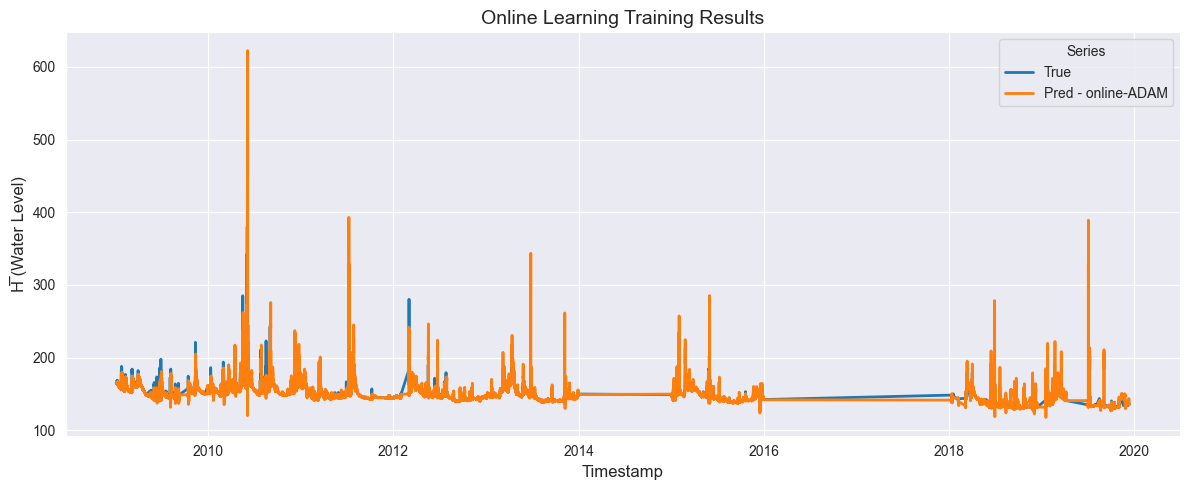

Appended metrics to CSV: results/training\Online Learning Training Results.csv


In [4]:
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              train_ds, train_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-ADAM": (y_true, y_pred, time_indices)}, 
                              plot_title="Online Learning Training Results",
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/training/Online Learning Training Results')

## Fix 1: Gradient Clipping
Clips gradients to prevent large normalized-loss spikes from destabilizing the model weights.


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.095382
   Batch 200/2461, Loss: 0.000877
   Batch 300/2461, Loss: 0.109843
   Batch 400/2461, Loss: 0.023150
   Batch 500/2461, Loss: 0.006602
   Batch 600/2461, Loss: 0.349199
   Batch 700/2461, Loss: 0.439190
   Batch 800/2461, Loss: 0.002227
   Batch 900/2461, Loss: 157.039215
   Batch 1000/2461, Loss: 0.069719
   Batch 1100/2461, Loss: 0.117739
   Batch 1200/2461, Loss: 0.179924
   Batch 1300/2461, Loss: 0.007436
   Batch 1400/2461, Loss: 0.158563
   Batch 1500/2461, Loss: 0.002485
   Batch 1600/2461, Loss: 2.703615
   Batch 1700/2461, Loss: 3.731286
   Batch 1800/2461, Loss: 0.051194
   Batch 1900/2461, Loss: 194950643712.000000
   Batch 2000/2461, Loss: 0.003779
   Batch 2100/2461, Loss: 1.457660
   Batch 2200/2461, Loss: 0.112151
   Batch 2300/2461, Loss: 0.108902
   Batch 2400/2461, Loss: 0.009747
   Batch 2461/2461, Loss: 0.028044
Training complete.


============== FINAL COMPARISON ==============
Grad

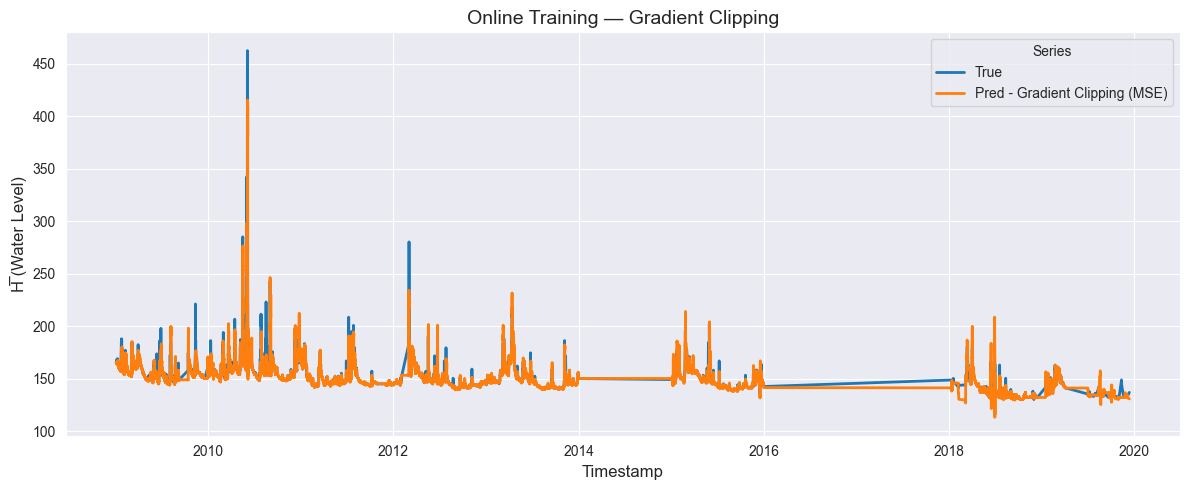

In [5]:
import importlib; importlib.reload(uf)

# Fix 1: Gradient Clipping — same MSE loss, but clip gradients to max_norm=1.0
model_gc, optimizer_gc, criterion_gc = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true_gc, y_pred_gc, time_indices_gc, losses_gc = uf.train_model_online(
    model_gc, optimizer_gc, criterion_gc,
    train_ds, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0
)

uf.calculate_metrics_and_plot({"Gradient Clipping (MSE)": (y_true_gc, y_pred_gc, time_indices_gc)},
                              plot_title="Online Training — Gradient Clipping")

## Testing Always updating
See model behaviour if we allowed it to learn on the fly from the testing data.<br>
**conclusion**<br>
Model's performance metrics went up as we all model to optimize and generalize more. In contarst model ability to adapt in lowered.<br>
We need to investigate more about optimizers and the adaptability, generalization trade-off.


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 0.170965
   Batch 200/2461, Loss: 0.001964
   Batch 300/2461, Loss: 0.143758
   Batch 400/2461, Loss: 0.021710
   Batch 500/2461, Loss: 0.011417
   Batch 600/2461, Loss: 0.250788
   Batch 700/2461, Loss: 0.430842
   Batch 800/2461, Loss: 0.003273
   Batch 900/2461, Loss: 158.022842
   Batch 1000/2461, Loss: 0.069545
   Batch 1100/2461, Loss: 0.079009
   Batch 1200/2461, Loss: 0.167543
   Batch 1300/2461, Loss: 0.005170
   Batch 1400/2461, Loss: 0.143231
   Batch 1500/2461, Loss: 0.009694
   Batch 1600/2461, Loss: 3.291777
   Batch 1700/2461, Loss: 4.692731
   Batch 1800/2461, Loss: 0.047906
   Batch 1900/2461, Loss: 194950545408.000000
   Batch 2000/2461, Loss: 0.004095
   Batch 2100/2461, Loss: 1.110369
   Batch 2200/2461, Loss: 0.208856
   Batch 2300/2461, Loss: 0.103641
   Batch 2400/2461, Loss: 0.010810
   Batch 2461/2461, Loss: 0.028428
Training complete.

Starting 'online' training with 728 batches...
   Ba

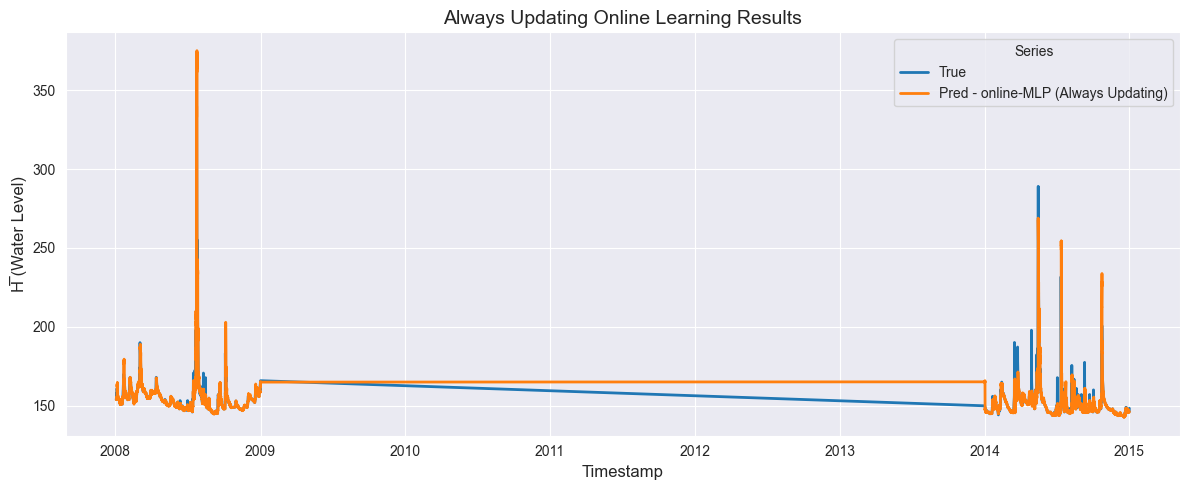

In [6]:
# Always updating: train on training set first, then continue training on test set
model_au, optimizer_au, criterion_au = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

# Phase 1: Train on training set
y_true_tr, y_pred_tr, time_indices_tr, losses_tr = uf.train_model_online(
    model_au, optimizer_au, criterion_au,
    train_ds, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0
)

# Phase 2: Continue training on test set (same model, no reset)
y_true_au, y_pred_au, time_indices_au, losses_au = uf.train_model_online(
    model_au, optimizer_au, criterion_au,
    test_ds, test_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0
)

# Plot results from the test set phase
uf.calculate_metrics_and_plot({"online-MLP (Always Updating)": (y_true_au, y_pred_au, time_indices_au)},
                              plot_title="Always Updating Online Learning Results")

## Z-Score Normalization vs Min-Max
Min-max maps the lookback window to [0,1], so any future value outside that range produces unbounded targets (y_scaled=10, -5, etc.).  
Z-score centers on 0 with unit variance — a future spike is only a few σ away, keeping losses stable.  
Below we rebuild the datasets with z-score normalization and re-run training + always-updating to compare.

In [7]:
import importlib; importlib.reload(uf)

# Build z-score normalized datasets
train_ds_z = uf.ZScoreNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds_z  = uf.ZScoreNormTimeSeriesDataset(x_test, y_test, H_BAR_INDEX)

# --- Z-Score: Train on training set, then evaluate on test set ---
model_z, optimizer_z, criterion_z = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
y_true_z, y_pred_z, ti_z, losses_z = uf.train_model_online(
    model_z, optimizer_z, criterion_z,
    train_ds_z, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0
)

y_true_z_test, y_pred_z_test, ti_z_test = uf.model_evaluate_with_norm(
    model_z, criterion_z, test_ds_z, test_df.index,
    LOOKBACK, HORIZON, BATCH_SIZE
)

# --- Z-Score: Always updating (train → then continue on test) ---
model_z_au, optimizer_z_au, criterion_z_au = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
# Phase 1: train set
_, _, _, _ = uf.train_model_online(
    model_z_au, optimizer_z_au, criterion_z_au,
    train_ds_z, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0
)
# Phase 2: continue on test set
y_true_z_au, y_pred_z_au, ti_z_au, losses_z_au = uf.train_model_online(
    model_z_au, optimizer_z_au, criterion_z_au,
    test_ds_z, test_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0
)

# --- Compare Z-Score vs Min-Max on test set ---
uf.calculate_metrics_and_plot({
    "Min-Max (test only)":         (y_true_test, y_pred_test, time_indices_test),
    "Z-Score (test only)":         (y_true_z_test, y_pred_z_test, ti_z_test),
    "Min-Max (always updating)":   (y_true_au, y_pred_au, time_indices_au),
    "Z-Score (always updating)":   (y_true_z_au, y_pred_z_au, ti_z_au),
}, plot_title="Normalization Comparison: Z-Score vs Min-Max")


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 11.220600
   Batch 200/2461, Loss: 0.052896
   Batch 300/2461, Loss: 0.391206
   Batch 400/2461, Loss: 0.471492
   Batch 500/2461, Loss: 0.113675
   Batch 600/2461, Loss: 0.127759
   Batch 700/2461, Loss: 5.411099
   Batch 800/2461, Loss: 0.801565
   Batch 900/2461, Loss: 7505.877441
   Batch 1000/2461, Loss: 3.147324
   Batch 1100/2461, Loss: 1.498811
   Batch 1200/2461, Loss: 0.739297
   Batch 1300/2461, Loss: 0.013072
   Batch 1400/2461, Loss: 1.115913
   Batch 1500/2461, Loss: 1.224503
   Batch 1600/2461, Loss: 118.432312
   Batch 1700/2461, Loss: 141.826248
   Batch 1800/2461, Loss: 0.816239
   Batch 1900/2461, Loss: 194949988352.000000
   Batch 2000/2461, Loss: 0.283984
   Batch 2100/2461, Loss: 11.659890
   Batch 2200/2461, Loss: 1.116601
   Batch 2300/2461, Loss: 0.483942
   Batch 2400/2461, Loss: 0.073480
   Batch 2461/2461, Loss: 1.366912
Training complete.
Testing complete.

Starting 'online' training 

NameError: name 'y_true_test' is not defined

## Combined Strategies for Always-Updating Online Learning
Goal: improve R² on the test set while keeping a good peak follow-up (fast adaptation).
All three experiments use **z-score normalization + gradient clipping**, train on the training set first, then keep updating on the test set.

1. **Exp 1** — Adam with aggressive betas `(0.85, 0.99)` for faster reaction to recent gradients.
2. **Exp 2** — Same setup but swap Adam for **RMSprop**.
3. **Exp 3** — Exp 1 + **River ADWIN** concept drift detection. On drift: clear optimizer state and temporarily boost LR, then return to normal. Multiple hyperparameter configs explored.

Run cells **in order** — Exp 3 references `y_true_adam` / `y_true_rms` from Exp 1 & 2 for the final comparison plot.

In [ ]:
# ============================================================================
# Combined always-updating experiments - all strategies in one cell.
# All use min-max normalization + tight gradient clipping (0.5) plus softer
# optimizer settings. Pretrain on training set, then keep updating on test set.
#
# Exp 3 uses the 4 best ADWIN configs from the hyperparameter search, feeding
# per-hour absolute errors (not batch loss) so behavior matches the search.
# ============================================================================
import importlib; importlib.reload(uf)
import numpy as np
import torch
from collections import defaultdict
from torch.utils.data import DataLoader
from river.drift import ADWIN

train_ds_mm = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds_mm  = uf.RollingNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX)

# Shared stability settings
GRAD_CLIP  = 1.2
ADAM_LR    = 5e-4
ADAM_BETAS = (0.9, 0.999)
RMS_LR     = 5e-4
RMS_ALPHA  = 0.99

all_results = {}

# ---------------------------------------------------------------------------
# Exp 1: Adam with standard betas
# ---------------------------------------------------------------------------
print("\n########## Exp 1: Adam (stable) ##########")
model_adam, _, criterion_adam = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=ADAM_LR, betas=ADAM_BETAS)
uf.train_model_online(model_adam, optimizer_adam, criterion_adam,
                      train_ds_mm, train_df, LOOKBACK, HORIZON, BATCH_SIZE,
                      max_grad_norm=GRAD_CLIP)
y_true_adam, y_pred_adam, ti_adam, _ = uf.train_model_online(
    model_adam, optimizer_adam, criterion_adam,
    test_ds_mm, test_df, LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=GRAD_CLIP)
all_results["Adam (stable)"] = (y_true_adam, y_pred_adam, ti_adam)

# ---------------------------------------------------------------------------
# Exp 2: RMSprop with heavier smoothing
# ---------------------------------------------------------------------------
print("\n########## Exp 2: RMSprop (stable) ##########")
model_rms, _, criterion_rms = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
optimizer_rms = torch.optim.RMSprop(model_rms.parameters(), lr=RMS_LR, alpha=RMS_ALPHA)
uf.train_model_online(model_rms, optimizer_rms, criterion_rms,
                      train_ds_mm, train_df, LOOKBACK, HORIZON, BATCH_SIZE,
                      max_grad_norm=GRAD_CLIP)
y_true_rms, y_pred_rms, ti_rms, _ = uf.train_model_online(
    model_rms, optimizer_rms, criterion_rms,
    test_ds_mm, test_df, LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=GRAD_CLIP)
all_results["RMSprop (stable)"] = (y_true_rms, y_pred_rms, ti_rms)

# ---------------------------------------------------------------------------
# Exp 3: Stable Adam + ADWIN drift detection on per-hour absolute errors.
# On drift: reset optimizer state and temporarily boost LR, then restore.
#
# The 4 ADWIN configs below are the top performers from the hyperparameter
# search (all 100% recall on the 2 real flood events in the test set).
# ---------------------------------------------------------------------------
drift_configs = [
    {
        "name": "baseline_default",
        "adwin": {"delta": 0.002, "clock": 32, "grace_period": 10, "min_window_length": 5},
        "lr_boost": 3e-3, "boost_batches": 5,
    },
    {
        "name": "very_fast_c4_g5",
        "adwin": {"delta": 0.002, "clock":  4, "grace_period":  5, "min_window_length": 5},
        "lr_boost": 3e-3, "boost_batches": 5,
    },
    {
        "name": "fast_clock_c8",
        "adwin": {"delta": 0.002, "clock":  8, "grace_period": 10, "min_window_length": 5},
        "lr_boost": 3e-3, "boost_batches": 5,
    },
    {
        "name": "max_sens_0.05_c4",
        "adwin": {"delta": 0.05,  "clock":  4, "grace_period":  3, "min_window_length": 3},
        "lr_boost": 3e-3, "boost_batches": 5,
    },
]
LR_NORMAL = 1e-3   # ADWIN-run base LR (overrides ADAM_LR for Exp 3)

def _make_adwin(params):
    try:
        return ADWIN(**params)
    except TypeError:
        return ADWIN(delta=params["delta"])

for cfg in drift_configs:
    print(f"\n########## Exp 3: {cfg['name']} ##########")
    model_d, _, criterion_d = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
    optimizer_d = torch.optim.Adam(model_d.parameters(), lr=LR_NORMAL, betas=ADAM_BETAS)

    # Phase 1: normal online training on training set
    uf.train_model_online(model_d, optimizer_d, criterion_d,
                          train_ds_mm, train_df, LOOKBACK, HORIZON, BATCH_SIZE,
                          max_grad_norm=GRAD_CLIP)

    # Phase 2: always-updating on test set with ADWIN drift detection.
    # Feed per-hour absolute errors (matches the hyperparameter search).
    drift = _make_adwin(cfg["adwin"])
    test_loader = DataLoader(test_ds_mm, batch_size=BATCH_SIZE, shuffle=False)
    y_gt = np.array([0.0]).reshape(1, 1)
    y_pr = np.array([0.0]).reshape(1, 1)
    idx_list = np.array([''])
    boost_remaining = 0
    drift_count = 0

    model_d.train()
    for i, (x_b, y_b, h_c, h_s) in enumerate(test_loader):
        y_hat = model_d(x_b)
        h_s_u, h_c_u = h_s.unsqueeze(-1), h_c.unsqueeze(-1)
        y_hat_u = (y_hat * h_s_u + h_c_u).detach().cpu().numpy()
        y_b_u   = (y_b   * h_s_u + h_c_u).detach().cpu().numpy()
        y_pr = np.concatenate((y_pr, y_hat_u), axis=1)
        y_gt = np.concatenate((y_gt, y_b_u),   axis=1)
        s = i*HORIZON + LOOKBACK
        idx_list = np.concatenate((idx_list, test_df.index[s:s+HORIZON]))

        # Feed per-hour absolute errors into ADWIN
        abs_err = np.abs(y_hat_u.flatten() - y_b_u.flatten())
        batch_has_drift = False
        for e in abs_err:
            drift.update(float(e))
            detected = getattr(drift, "drift_detected", None)
            if detected is None:
                detected = getattr(drift, "change_detected", False)
            if detected:
                batch_has_drift = True
                break

        # Cooldown: only react to a fresh drift when not already boosted.
        # Skip the optimizer state reset - Adam m/v encode long-term stats
        # and wiping them on every drift obliterates learning.
        if batch_has_drift and boost_remaining == 0:
            drift_count += 1
            for pg in optimizer_d.param_groups:
                pg['lr'] = cfg["lr_boost"]
            boost_remaining = cfg["boost_batches"]
        elif boost_remaining > 0:
            boost_remaining -= 1
            if boost_remaining == 0:
                for pg in optimizer_d.param_groups:
                    pg['lr'] = LR_NORMAL

        loss = criterion_d(y_hat, y_b)
        optimizer_d.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_d.parameters(), max_norm=GRAD_CLIP)
        optimizer_d.step()

    print(f"  total drifts detected: {drift_count}")
    all_results[cfg["name"]] = (y_gt[:, 1:].flatten(),
                                y_pr[:, 1:].flatten(),
                                idx_list[1:].flatten())

# ---------------------------------------------------------------------------
# Final comparison plot - all strategies on one figure
# ---------------------------------------------------------------------------
uf.calculate_metrics_and_plot(
    all_results,
    plot_title="Always-Updating Online Learning - Strategy Comparison (Min-Max, Stabilized, Tuned ADWIN)",
    export_metrics=True,
    export_html=True,
    export_file_name='results/testing/online/always_updating_strategy_comparison'
)


In [ ]:
# ============================================================================
# Flood-event vs ADWIN drift-detection alignment check.
# Question: when the water level actually spikes (flood), does ADWIN fire?
#
# Approach:
#   1. Pretrain a stable Adam model on the training set.
#   2. Run always-updating on the test set, feeding per-batch loss to ADWIN.
#   3. Record (batch_idx, timestamp) for every drift event.
#   4. Label flood events in the ground truth H_bar using a percentile threshold.
#   5. Plot H_bar over time with both flood regions and drift markers overlaid.
#   6. Report detection/recall/latency statistics.
# ============================================================================
import importlib; importlib.reload(uf)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import DataLoader
from river.drift import ADWIN

# --- Config -----------------------------------------------------------------
DRIFT_DELTA      = 0.002   # ADWIN sensitivity (smaller = more sensitive)
FLOOD_PERCENTILE = 90      # H_bar above this percentile is considered flood
FLOOD_MIN_GAP_H  = 24      # merge flood hours closer than this into one event
TOLERANCE_H      = 48      # drift counts as a hit if within ±this many hours of a flood
GRAD_CLIP        = 0.5
ADAM_LR          = 5e-4
ADAM_BETAS       = (0.9, 0.999)

train_ds_mm = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds_mm  = uf.RollingNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX)

# --- Phase 1: pretrain on training set --------------------------------------
print("### Pretraining on training set ###")
model_d, _, criterion_d = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
optimizer_d = torch.optim.Adam(model_d.parameters(), lr=ADAM_LR, betas=ADAM_BETAS)
uf.train_model_online(model_d, optimizer_d, criterion_d,
                      train_ds_mm, train_df, LOOKBACK, HORIZON, BATCH_SIZE,
                      max_grad_norm=GRAD_CLIP)

# --- Phase 2: always-updating on test set with ADWIN ------------------------
print(f"\n### Always-updating on test set with ADWIN (delta={DRIFT_DELTA}) ###")
drift = ADWIN(delta=DRIFT_DELTA)
test_loader = DataLoader(test_ds_mm, batch_size=BATCH_SIZE, shuffle=False)

drift_events = []      # list of (batch_idx, timestamp, loss)
batch_losses = []
y_gt = np.array([0.0]).reshape(1, 1)
y_pr = np.array([0.0]).reshape(1, 1)
idx_list = np.array([''])

model_d.train()
for i, (x_b, y_b, h_c, h_s) in enumerate(test_loader):
    y_hat = model_d(x_b)
    h_s_u, h_c_u = h_s.unsqueeze(-1), h_c.unsqueeze(-1)
    y_hat_u = (y_hat * h_s_u + h_c_u).detach().cpu().numpy()
    y_b_u   = (y_b   * h_s_u + h_c_u).detach().cpu().numpy()
    y_pr = np.concatenate((y_pr, y_hat_u), axis=1)
    y_gt = np.concatenate((y_gt, y_b_u),   axis=1)
    s = i*HORIZON + LOOKBACK
    idx_list = np.concatenate((idx_list, test_df.index[s:s+HORIZON]))

    loss = criterion_d(y_hat, y_b)
    cur_loss = loss.item()
    batch_losses.append(cur_loss)

    drift.update(cur_loss)
    if drift.drift_detected:
        # Timestamp of the first prediction in this batch
        drift_events.append((i, test_df.index[s], cur_loss))

    optimizer_d.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_d.parameters(), max_norm=GRAD_CLIP)
    optimizer_d.step()

y_true_flat = y_gt[:, 1:].flatten()
y_pred_flat = y_pr[:, 1:].flatten()
timestamps  = pd.to_datetime(idx_list[1:].flatten())

print(f"\nTotal drifts detected: {len(drift_events)}")

# --- Label flood events in ground truth -------------------------------------
flood_threshold = np.percentile(y_true_flat, FLOOD_PERCENTILE)
print(f"Flood threshold (H_bar > {FLOOD_PERCENTILE}th pct): {flood_threshold:.3f}")

# Build a DataFrame of (timestamp, H_bar, is_flood) and group consecutive flood hours
flood_df = pd.DataFrame({"ts": timestamps, "h": y_true_flat})
flood_df["is_flood"] = flood_df["h"] > flood_threshold

# Group consecutive flood hours into events, merging gaps < FLOOD_MIN_GAP_H
flood_events = []
in_event = False
event_start = None
last_flood_idx = -10**9
for idx, row in flood_df.iterrows():
    if row["is_flood"]:
        if not in_event:
            # gap-merge: keep extending if the previous event ended recently
            if event_start is not None and (idx - last_flood_idx) < FLOOD_MIN_GAP_H:
                in_event = True
            else:
                event_start = idx
                in_event = True
        last_flood_idx = idx
    else:
        if in_event and (idx - last_flood_idx) >= FLOOD_MIN_GAP_H:
            flood_events.append((event_start, last_flood_idx))
            in_event = False
            event_start = None
if in_event:
    flood_events.append((event_start, last_flood_idx))

print(f"Flood events identified: {len(flood_events)}")
for s_i, e_i in flood_events:
    print(f"  {flood_df['ts'].iloc[s_i]}  ->  {flood_df['ts'].iloc[e_i]}  "
          f"(peak H_bar = {flood_df['h'].iloc[s_i:e_i+1].max():.3f})")

# --- Hit / miss / latency analysis ------------------------------------------
# A drift is a "hit" if it fires within TOLERANCE_H hours of any flood event window.
drift_timestamps = [ev[1] for ev in drift_events]
tolerance = pd.Timedelta(hours=TOLERANCE_H)

hits_per_flood = []
for s_i, e_i in flood_events:
    start_t = flood_df["ts"].iloc[s_i] - tolerance
    end_t   = flood_df["ts"].iloc[e_i] + tolerance
    matching = [dt for dt in drift_timestamps if start_t <= dt <= end_t]
    hits_per_flood.append(len(matching))

flood_detected = sum(1 for h in hits_per_flood if h > 0)
recall = flood_detected / len(flood_events) if flood_events else 0.0

# False-positive drifts = drifts not near any flood
fp = 0
for dt in drift_timestamps:
    matched = False
    for s_i, e_i in flood_events:
        start_t = flood_df["ts"].iloc[s_i] - tolerance
        end_t   = flood_df["ts"].iloc[e_i] + tolerance
        if start_t <= dt <= end_t:
            matched = True
            break
    if not matched:
        fp += 1

print(f"\n=== Flood-vs-Drift alignment (±{TOLERANCE_H}h tolerance) ===")
print(f"Flood events detected:   {flood_detected}/{len(flood_events)}  (recall = {recall:.2%})")
print(f"False-positive drifts:   {fp}/{len(drift_events)}")

# --- Plot H_bar with flood regions + drift markers --------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# Top: ground-truth H_bar with flood shading and drift vlines
axes[0].plot(timestamps, y_true_flat, label="True H_bar", color="#1f77b4", lw=1)
axes[0].axhline(flood_threshold, color="orange", ls="--", lw=1,
                label=f"Flood threshold (p{FLOOD_PERCENTILE})")
for s_i, e_i in flood_events:
    axes[0].axvspan(flood_df["ts"].iloc[s_i], flood_df["ts"].iloc[e_i],
                    color="red", alpha=0.15)
for _, dt, _ in drift_events:
    axes[0].axvline(dt, color="purple", ls=":", lw=1, alpha=0.8)
axes[0].set_ylabel("H_bar")
axes[0].set_title(f"Flood events (red shade) vs ADWIN drift detections (purple ticks) "
                  f"— {flood_detected}/{len(flood_events)} floods detected")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# Bottom: per-batch loss with drift markers
batch_ts = pd.DatetimeIndex([test_df.index[i*HORIZON + LOOKBACK] for i in range(len(batch_losses))])
axes[1].plot(batch_ts, batch_losses, color="#2ca02c", lw=1, label="Batch loss")
for _, dt, _ in drift_events:
    axes[1].axvline(dt, color="purple", ls=":", lw=1, alpha=0.8)
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Timestamp")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/testing/online/flood_vs_drift_alignment.png", dpi=150)
plt.show()
print("Saved: results/testing/online/flood_vs_drift_alignment.png")

In [ ]:
# ============================================================================
# ADWIN hyperparameter search for flood-detection quality.
#
# Feeds per-HOUR absolute errors in ORIGINAL H_bar units (meters) into ADWIN.
# Flood events = contiguous hours where H_bar exceeds an absolute threshold
# (250 — there are 2 real flood events in this test set).
# ============================================================================
import importlib; importlib.reload(uf)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from river.drift import ADWIN

# --- Config -----------------------------------------------------------------
FLOOD_ABS_THRESHOLD = 250     # H_bar above this is flood; 2 events in this test set
FLOOD_MIN_GAP_H     = 24      # merge flood hours closer than this into one event
TOLERANCE_H         = 48      # drift counts as a hit if within +/- this many hours of a flood
GRAD_CLIP           = 0.5
ADAM_LR             = 5e-4
ADAM_BETAS          = (0.9, 0.999)

# 9 ADWIN configs sweeping delta (confidence), clock, grace_period, min_window_length
adwin_configs = [
    {"name": "baseline_default",   "delta": 0.002, "clock": 32, "grace_period": 10, "min_window_length": 5},
    {"name": "strict_1e-5",        "delta": 1e-5,  "clock": 32, "grace_period": 10, "min_window_length": 5},
    {"name": "sensitive_0.01",     "delta": 0.01,  "clock": 32, "grace_period": 10, "min_window_length": 5},
    {"name": "very_sens_0.05",     "delta": 0.05,  "clock": 32, "grace_period": 10, "min_window_length": 5},
    {"name": "fast_clock_c8",      "delta": 0.002, "clock": 8,  "grace_period": 10, "min_window_length": 5},
    {"name": "very_fast_c4_g5",    "delta": 0.002, "clock": 4,  "grace_period": 5,  "min_window_length": 5},
    {"name": "small_win_g5_mw3",   "delta": 0.002, "clock": 32, "grace_period": 5,  "min_window_length": 3},
    {"name": "aggressive_0.01_c8", "delta": 0.01,  "clock": 8,  "grace_period": 5,  "min_window_length": 3},
    {"name": "max_sens_0.05_c4",   "delta": 0.05,  "clock": 4,  "grace_period": 3,  "min_window_length": 3},
]

train_ds_mm = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds_mm  = uf.RollingNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX)

# --- Phase 1: pretrain on training set --------------------------------------
print("### Pretraining on training set ###")
model_d, _, criterion_d = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
optimizer_d = torch.optim.Adam(model_d.parameters(), lr=ADAM_LR, betas=ADAM_BETAS)
uf.train_model_online(model_d, optimizer_d, criterion_d,
                      train_ds_mm, train_df, LOOKBACK, HORIZON, BATCH_SIZE,
                      max_grad_norm=GRAD_CLIP)

# --- Phase 2: always-updating on test set, cache per-hour absolute errors ---
print("\n### Collecting per-hour error stream on test set (always-updating) ###")
test_loader = DataLoader(test_ds_mm, batch_size=BATCH_SIZE, shuffle=False)

hourly_abs_errors = []
hourly_timestamps = []
y_gt_chunks = []

model_d.train()
for i, (x_b, y_b, h_c, h_s) in enumerate(test_loader):
    y_hat = model_d(x_b)

    h_s_u, h_c_u = h_s.unsqueeze(-1), h_c.unsqueeze(-1)
    y_hat_u = (y_hat * h_s_u + h_c_u).detach().cpu().numpy().flatten()
    y_b_u   = (y_b   * h_s_u + h_c_u).detach().cpu().numpy().flatten()
    y_gt_chunks.append(y_b_u)

    abs_err = np.abs(y_hat_u - y_b_u)
    hourly_abs_errors.extend(abs_err.tolist())

    s = i*HORIZON + LOOKBACK
    chunk_ts = test_df.index[s:s+HORIZON]
    hourly_timestamps.extend(list(chunk_ts))

    loss = criterion_d(y_hat, y_b)
    optimizer_d.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_d.parameters(), max_norm=GRAD_CLIP)
    optimizer_d.step()

hourly_abs_errors = np.array(hourly_abs_errors, dtype=np.float64)
hourly_timestamps = pd.DatetimeIndex(hourly_timestamps)
y_true_flat = np.concatenate(y_gt_chunks)
timestamps  = hourly_timestamps

print(f"Collected {len(hourly_abs_errors)} per-hour error samples")
print(f"Error stats: mean={hourly_abs_errors.mean():.4f}  std={hourly_abs_errors.std():.4f}  "
      f"min={hourly_abs_errors.min():.4f}  max={hourly_abs_errors.max():.4f}")

# --- Label flood events in ground truth using an ABSOLUTE H_bar threshold --
print(f"\nFlood threshold (absolute): H_bar > {FLOOD_ABS_THRESHOLD}")
print(f"H_bar stats on test set: min={y_true_flat.min():.2f}  max={y_true_flat.max():.2f}  "
      f"mean={y_true_flat.mean():.2f}")

is_flood = y_true_flat > FLOOD_ABS_THRESHOLD

flood_runs = []
N = len(is_flood)
i = 0
while i < N:
    if is_flood[i]:
        j = i
        while j + 1 < N and is_flood[j + 1]:
            j += 1
        flood_runs.append((i, j))
        i = j + 1
    else:
        i += 1

merged = []
for run in flood_runs:
    if merged and (run[0] - merged[-1][1]) < FLOOD_MIN_GAP_H:
        merged[-1] = (merged[-1][0], run[1])
    else:
        merged.append(run)
flood_runs = merged
print(f"Flood events identified: {len(flood_runs)}")
for s_i, e_i in flood_runs:
    peak = float(y_true_flat[s_i:e_i+1].max())
    dur_h = e_i - s_i + 1
    print(f"  {timestamps[s_i]}  ->  {timestamps[e_i]}  "
          f"(duration={dur_h}h, peak H_bar={peak:.2f})")

tolerance = pd.Timedelta(hours=TOLERANCE_H)

def evaluate_adwin(cfg):
    """Run ADWIN over the cached per-hour error stream and compute metrics."""
    try:
        adwin = ADWIN(delta=cfg["delta"],
                      clock=cfg["clock"],
                      grace_period=cfg["grace_period"],
                      min_window_length=cfg["min_window_length"])
    except TypeError:
        adwin = ADWIN(delta=cfg["delta"])

    drift_ts = []
    for i, e in enumerate(hourly_abs_errors):
        adwin.update(float(e))
        detected = getattr(adwin, "drift_detected", None)
        if detected is None:
            detected = getattr(adwin, "change_detected", False)
        if detected:
            drift_ts.append(hourly_timestamps[i])

    # Per-flood recall
    tp_floods = 0
    for s_i, e_i in flood_runs:
        start_t = timestamps[s_i] - tolerance
        end_t   = timestamps[e_i] + tolerance
        if any(start_t <= dt <= end_t for dt in drift_ts):
            tp_floods += 1

    # Per-drift precision
    tp_drifts = 0
    for dt in drift_ts:
        for s_i, e_i in flood_runs:
            if (timestamps[s_i] - tolerance) <= dt <= (timestamps[e_i] + tolerance):
                tp_drifts += 1
                break
    fp_drifts = len(drift_ts) - tp_drifts

    n_floods = len(flood_runs)
    n_drifts = len(drift_ts)
    recall    = tp_floods / n_floods if n_floods else 0.0
    precision = tp_drifts / n_drifts if n_drifts else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return {
        "n_drifts": n_drifts,
        "tp_floods": tp_floods,
        "fp_drifts": fp_drifts,
        "recall": recall,
        "precision": precision,
        "f1": f1,
        "drift_timestamps": drift_ts,
    }

# --- Run all configs -------------------------------------------------------
print("\n### ADWIN hyperparameter search ###")
results = []
for cfg in adwin_configs:
    m = evaluate_adwin(cfg)
    results.append({**cfg, **m})
    print(f"  {cfg['name']:25s}  drifts={m['n_drifts']:4d}  "
          f"recall={m['recall']:6.2%}  prec={m['precision']:6.2%}  f1={m['f1']:.3f}")

df_results = pd.DataFrame(results)
df_display = df_results[["name", "delta", "clock", "grace_period", "min_window_length",
                         "n_drifts", "tp_floods", "fp_drifts",
                         "recall", "precision", "f1"]].sort_values("f1", ascending=False)
print("\n=== Results (sorted by F1) ===")
print(df_display.to_string(index=False))

df_display.to_csv("results/testing/online/adwin_hparam_search.csv", index=False)
print("\nSaved: results/testing/online/adwin_hparam_search.csv")

best = df_display.iloc[0]
print(f"\nBest config: {best['name']}  "
      f"(recall={best['recall']:.2%}, precision={best['precision']:.2%}, f1={best['f1']:.3f})")

# --- Plot: best config on H_bar + bar chart of all configs -----------------
best_result = next(r for r in results if r["name"] == best["name"])

fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                         gridspec_kw={"height_ratios": [3, 2]})

axes[0].plot(timestamps, y_true_flat, label="True H_bar", color="#1f77b4", lw=1)
axes[0].axhline(FLOOD_ABS_THRESHOLD, color="orange", ls="--", lw=1,
                label=f"Flood threshold (H_bar > {FLOOD_ABS_THRESHOLD})")
for s_i, e_i in flood_runs:
    axes[0].axvspan(timestamps[s_i], timestamps[e_i], color="red", alpha=0.2)
for dt in best_result["drift_timestamps"]:
    axes[0].axvline(dt, color="purple", ls=":", lw=1.2, alpha=0.6)
axes[0].set_ylabel("H_bar")
axes[0].set_title(f"Best ADWIN config: {best['name']} - "
                  f"recall={best['recall']:.2%}, precision={best['precision']:.2%}, "
                  f"f1={best['f1']:.3f}")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

x_pos = np.arange(len(df_display))
width = 0.25
axes[1].bar(x_pos - width, df_display["recall"],    width, label="recall",    color="#2ca02c")
axes[1].bar(x_pos,         df_display["precision"], width, label="precision", color="#ff7f0e")
axes[1].bar(x_pos + width, df_display["f1"],        width, label="f1",        color="#9467bd")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(df_display["name"], rotation=35, ha="right", fontsize=8)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Score")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3, axis="y")
axes[1].set_title("ADWIN hyperparameter search - recall / precision / F1")

plt.tight_layout()
plt.savefig("results/testing/online/adwin_hparam_search.png", dpi=150)
plt.show()
print("Saved: results/testing/online/adwin_hparam_search.png")
